# Wpływ augmentacji oświetleniowej na odporność modelu ResNet50

Celem eksperymentu jest określenie, czy zastosowanie losowej augmentacji oświetleniowej podczas treningu modelu ResNet50 zwiększa jego odporność na zmienne warunki oświetleniowe.

Porównane zostaną dwie konfiguracje:

- model trenowany na obrazach bez dodatkowej augmentacji oświetleniowej,
- model trenowany z losową zmianą jasności i kontrastu obrazów.

Obie konfiguracje wykorzystują identyczną architekturę `ResNet50`, strategię `WeightedRandomSampler` oraz identyczne parametry procesu uczenia.

Ocena odporności zostanie przeprowadzona dla obrazu oryginalnego oraz trzech kontrolowanych poziomów zaciemnienia.

Wybór konfiguracji odbywa się na podstawie wyników zbioru walidacyjnego.

Niezależny zbiór `test_final` zostanie wykorzystany wyłącznie do końcowej oceny wybranej konfiguracji.

In [ ]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import (
    classification_report,
)

PROJECT_ROOT = Path(
    r"C:\Users\Dell\Desktop\Kacper Błachowiak - praca magisterska - klasyfikacja znaków drogowych\KB_Praca_Magisterska"
)


if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )


from src.data.dataset import (
    TrafficSignDataset,
)

from src.data.transforms import (
    build_train_transform,
    build_eval_transform,
)

from src.data.sampling import (
    build_weighted_sampler,
)

from src.data.lighting_augmentation import (
    ControlledLightingDataset,
    LIGHTING_FACTORS,
    RandomLightingAugmentation,
)

from src.models.resnet50 import (
    create_resnet50,
    freeze_resnet50_backbone,
    unfreeze_resnet50_last_block,
)

from src.training.trainer import (
    fit,
)

from src.evaluation.metrics import (
    predict,
    evaluate_predictions,
)

from src.utils.seed import (
    set_seed,
)


set_seed(42)


METADATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "data"
    / "processed"
    / "metadata"
)


RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
)


METRICS_DIR = (
    RESULTS_DIR
    / "metrics"
)


HISTORIES_DIR = (
    RESULTS_DIR
    / "histories"
)


CHECKPOINT_DIR = (
    PROJECT_ROOT
    / "models"
    / "checkpoints"
)


REPORTS_DIR = (
    PROJECT_ROOT
    / "reports"
    / "lighting_augmentation"
)


FIGURES_DIR = (
    REPORTS_DIR
    / "figures"
)


for directory in [
    METRICS_DIR,
    HISTORIES_DIR,
    CHECKPOINT_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )


DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print(
    "Urządzenie:",
    DEVICE
)

Urządzenie: cpu


## 1. Konfiguracja eksperymentu

In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 0
FROZEN_EPOCHS = 10
FINE_TUNE_EPOCHS = 5
FROZEN_LR = 1e-3
FINE_TUNE_LR = 1e-5
RANDOM_SEED = 42
PRETRAINED = True

CONFIGURATIONS = [
    {
        "name": "original",
        "lighting_augmentation": False,
    },

    {
        "name": "lighting_augmentation",
        "lighting_augmentation": True,
    },
]


LIGHTING_VARIANTS = [
    "original",
    "dark_1",
    "dark_2",
    "dark_3",
]


print(
    "Konfiguracje:"
)

for configuration in CONFIGURATIONS:

    print(
        configuration
    )

Konfiguracje:
{'name': 'original', 'lighting_augmentation': False}
{'name': 'lighting_augmentation', 'lighting_augmentation': True}


## 2. Manifesty danych i mapowanie klas

In [3]:
TRAIN_PATH = (
    METADATA_DIR
    / "07_train.csv"
)

VALIDATION_PATH = (
    METADATA_DIR
    / "08_validation.csv"
)

TEST_PATH = (
    METADATA_DIR
    / "09_test_final.csv"
)


train_df = pd.read_csv(
    TRAIN_PATH
)

validation_df = pd.read_csv(
    VALIDATION_PATH
)

test_df = pd.read_csv(
    TEST_PATH
)


class_codes = sorted(
    set(
        train_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        validation_df[
            "class_code"
        ].astype(str)
    )
    |
    set(
        test_df[
            "class_code"
        ].astype(str)
    )
)


class_to_idx = {
    class_code: index
    for index, class_code
    in enumerate(class_codes)
}


idx_to_class = {
    index: class_code
    for class_code, index
    in class_to_idx.items()
}


print(
    "Liczba klas:",
    len(class_codes)
)

print(
    "TRAIN:",
    len(train_df)
)

print(
    "VALIDATION:",
    len(validation_df)
)

print(
    "TEST_FINAL:",
    len(test_df)
)

Liczba klas: 92
TRAIN: 14232
VALIDATION: 2512
TEST_FINAL: 4298


## 3. Transformacje treningowe

Konfiguracja bazowa wykorzystuje standardową procedurę przygotowania obrazów.

W konfiguracji z augmentacją oświetleniową przed zmianą rozmiaru obrazu stosowana jest losowa modyfikacja jasności i kontrastu.

Augmentacja występuje wyłącznie podczas treningu.

In [4]:
from torchvision import transforms


normalization = transforms.Normalize(
    mean=(
        0.485,
        0.456,
        0.406,
    ),
    std=(
        0.229,
        0.224,
        0.225,
    ),
)


def build_training_transform(
    use_lighting_augmentation=False,
):

    transform_list = []


    if use_lighting_augmentation:

        transform_list.append(
            RandomLightingAugmentation(
                brightness_range=(
                    0.5,
                    1.3,
                ),
                contrast_range=(
                    0.8,
                    1.2,
                ),
                probability=0.8,
            )
        )


    transform_list.extend(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.RandomRotation(
                10
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )


    return transforms.Compose(
        transform_list
    )


def build_evaluation_transform():

    return transforms.Compose(
        [
            transforms.Resize(
                (
                    IMAGE_SIZE,
                    IMAGE_SIZE,
                )
            ),

            transforms.ToTensor(),

            normalization,
        ]
    )

## 4. Przygotowanie DataLoaderów

In [5]:
def build_training_loaders(
    use_lighting_augmentation,
):

    train_transform = (
        build_training_transform(
            use_lighting_augmentation
        )
    )


    validation_transform = (
        build_evaluation_transform()
    )


    train_dataset = (
        TrafficSignDataset(
            TRAIN_PATH,
            class_to_idx,
            transform=train_transform,
        )
    )


    validation_dataset = (
        TrafficSignDataset(
            VALIDATION_PATH,
            class_to_idx,
            transform=validation_transform,
        )
    )


    weighted_sampler = (
        build_weighted_sampler(
            TRAIN_PATH
        )
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=weighted_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    validation_loader = DataLoader(
        validation_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    return (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    )

## 5. Wizualna kontrola augmentacji oświetleniowej

Przed rozpoczęciem treningu przedstawiono przykładowe obrazy poddane losowym zmianom jasności i kontrastu.

Kontrola służy weryfikacji, czy zakres augmentacji odpowiada założeniom eksperymentu.

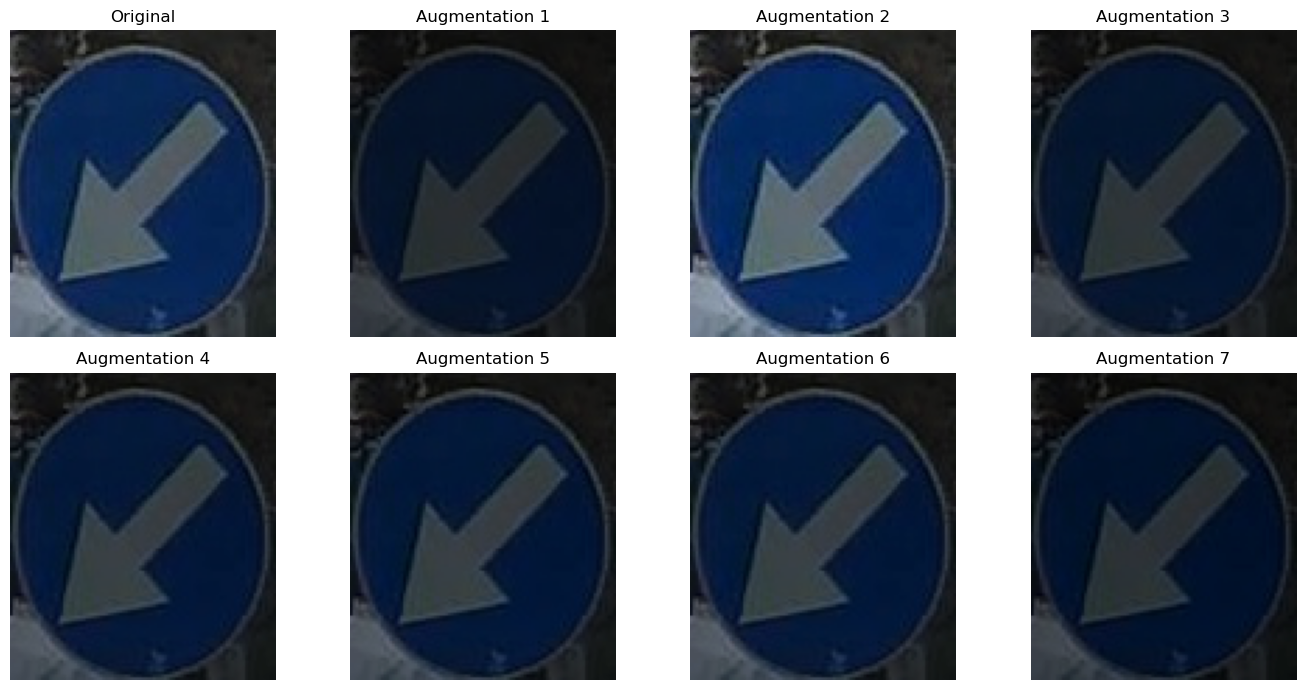

In [6]:
from PIL import Image


sample_path = Path(
    train_df.iloc[0][
        "path"
    ]
)


sample_image = Image.open(
    sample_path
).convert("RGB")


augmentation = (
    RandomLightingAugmentation(
        brightness_range=(
            0.5,
            1.3,
        ),
        contrast_range=(
            0.8,
            1.2,
        ),
        probability=1.0,
    )
)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 7),
)


axes = axes.reshape(-1)


axes[0].imshow(
    sample_image
)

axes[0].set_title(
    "Original"
)

axes[0].axis(
    "off"
)


for index in range(
    1,
    8,
):

    augmented = augmentation(
        sample_image
    )

    axes[index].imshow(
        augmented
    )

    axes[index].set_title(
        f"Augmentation {index}"
    )

    axes[index].axis(
        "off"
    )


plt.tight_layout()
plt.show()

## 6. Funkcja tworzenia modelu ResNet50

In [7]:
def create_model():

    model = create_resnet50(
        num_classes=len(
            class_codes
        ),
        pretrained=PRETRAINED,
    )


    model = (
        freeze_resnet50_backbone(
            model
        )
    )


    model = model.to(
        DEVICE
    )


    return model

## 7. Funkcja treningu pojedynczej konfiguracji

Każda konfiguracja przechodzi dwa etapy uczenia:

1. trening głowicy klasyfikacyjnej przy zamrożonym backbone,
2. fine-tuning końcowego bloku ResNet50 i głowicy klasyfikacyjnej.

Najlepszy model jest wybierany według `validation Macro F1`.

In [8]:
def train_configuration(
    configuration,
):

    name = configuration[
        "name"
    ]

    use_lighting_augmentation = (
        configuration[
            "lighting_augmentation"
        ]
    )


    print(
        "\n"
        + "=" * 80
    )

    print(
        f"Konfiguracja: {name}"
    )

    print(
        "=" * 80
    )


    set_seed(
        RANDOM_SEED
    )


    (
        train_dataset,
        validation_dataset,
        train_loader,
        validation_loader,
    ) = build_training_loaders(
        use_lighting_augmentation
    )


    model = create_model()


    criterion = (
        nn.CrossEntropyLoss()
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FROZEN_LR,
    )


    frozen_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{name}_"
            f"frozen_best.pt"
        )
    )


    frozen_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FROZEN_EPOCHS,
        checkpoint_path=frozen_checkpoint,
    )


    model = (
        unfreeze_resnet50_last_block(
            model
        )
    )


    optimizer = torch.optim.Adam(
        filter(
            lambda parameter:
            parameter.requires_grad,
            model.parameters(),
        ),
        lr=FINE_TUNE_LR,
    )


    finetuned_checkpoint = (
        CHECKPOINT_DIR
        / (
            f"resnet50_"
            f"{name}_"
            f"finetuned_best.pt"
        )
    )


    finetune_history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=validation_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        epochs=FINE_TUNE_EPOCHS,
        checkpoint_path=finetuned_checkpoint,
    )


    model.eval()


    return {
        "configuration":
            configuration,

        "model":
            model,

        "train_dataset":
            train_dataset,

        "validation_dataset":
            validation_dataset,

        "train_loader":
            train_loader,

        "validation_loader":
            validation_loader,

        "frozen_history":
            frozen_history,

        "finetune_history":
            finetune_history,
    }

## 8. Trening konfiguracji bazowej

In [9]:
original_experiment = (
    train_configuration(
        CONFIGURATIONS[0]
    )
)


Konfiguracja: original


Postęp treningu:   0%|          | 0/10 [00:00<?, ?it/s]

Epoka 1/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/10:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

## 9. Trening konfiguracji z augmentacją oświetleniową

In [10]:
augmentation_experiment = (
    train_configuration(
        CONFIGURATIONS[1]
    )
)


Konfiguracja: lighting_augmentation


Postęp treningu:   0%|          | 0/10 [00:00<?, ?it/s]

Epoka 1/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/10:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/10:   0%|          | 0/445 [00:00<?, ?it/s]

...

Epoka 1/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 2/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 3/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 4/5:   0%|          | 0/445 [00:00<?, ?it/s]

Epoka 5/5:   0%|          | 0/445 [00:00<?, ?it/s]

## 10. Zestawienie wytrenowanych modeli


In [11]:
experiments = {
    "original":
        original_experiment,

    "lighting_augmentation":
        augmentation_experiment,
}


print(
    "Modele:",
    list(
        experiments.keys()
    )
)

Modele: ['original', 'lighting_augmentation']


## 11. Skuteczność na standardowym zbiorze walidacyjnym

In [12]:
standard_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]

    loader = experiment[
        "validation_loader"
    ]


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    standard_results.append(
        {
            "configuration":
                name,

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "macro_precision":
                metrics[
                    "macro_precision"
                ],

            "macro_recall":
                metrics[
                    "macro_recall"
                ],

            "macro_f1":
                metrics[
                    "macro_f1"
                ],

            "inference_time_seconds":
                inference_time,
        }
    )


standard_validation_df = (
    pd.DataFrame(
        standard_results
    )
)


display(
    standard_validation_df
)

,configuration,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,0.937102,0.928367,0.931038,0.925461,205.419073
1,lighting_augmentation,0.938296,0.933700,0.934755,0.930392,209.669062


## 12. Funkcja oceny odporności na kontrolowane zaciemnienie

Wariant zaciemnienia jest zastosowany przed transformacją wejściową modelu.

Dla konfiguracji z augmentacją treningową podczas ewaluacji nie stosuje się już losowej augmentacji. Model jest oceniany deterministycznie na kontrolowanych wariantach obrazu.

In [13]:
def evaluate_lighting_variant(
    model,
    variant,
):

    transform = (
        build_evaluation_transform()
    )


    dataset = (
        ControlledLightingDataset(
            VALIDATION_PATH,
            class_to_idx,
            lighting_variant=variant,
            transform=transform,
        )
    )


    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=False,
    )


    y_true, y_pred, inference_time = (
        predict(
            model,
            loader,
            DEVICE,
        )
    )


    metrics = evaluate_predictions(
        y_true,
        y_pred,
    )


    return {
        "samples":
            len(dataset),

        "accuracy":
            metrics[
                "accuracy"
            ],

        "macro_precision":
            metrics[
                "macro_precision"
            ],

        "macro_recall":
            metrics[
                "macro_recall"
            ],

        "macro_f1":
            metrics[
                "macro_f1"
            ],

        "inference_time_seconds":
            inference_time,
    }

## 13. Ocena odporności na zaciemnienie

In [14]:
lighting_results = []


for name, experiment in (
    experiments.items()
):

    model = experiment[
        "model"
    ]


    for variant in LIGHTING_VARIANTS:

        print(
            f"Konfiguracja: {name} | "
            f"Wariant: {variant}"
        )


        metrics = (
            evaluate_lighting_variant(
                model=model,
                variant=variant,
            )
        )


        lighting_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                **metrics,
            }
        )


lighting_results_df = (
    pd.DataFrame(
        lighting_results
    )
)


display(
    lighting_results_df
)

Konfiguracja: original | Wariant: original
Konfiguracja: original | Wariant: dark_1
Konfiguracja: original | Wariant: dark_2
Konfiguracja: original | Wariant: dark_3
Konfiguracja: lighting_augmentation | Wariant: original
Konfiguracja: lighting_augmentation | Wariant: dark_1
Konfiguracja: lighting_augmentation | Wariant: dark_2
Konfiguracja: lighting_augmentation | Wariant: dark_3


,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,original,1.0,2512,0.937102,0.928367,0.931038,0.925461,187.677069
1,original,dark_1,0.7,2512,0.927150,0.915198,0.920027,0.913132,185.328016
2,original,dark_2,0.5,2512,0.916401,0.903615,0.896650,0.893409,192.023626
3,original,dark_3,0.3,2512,0.890924,0.881051,0.869156,0.863200,181.052502
4,lighting_augmentation,original,1.0,2512,0.938296,0.933700,0.934755,0.930392,186.590465
5,lighting_augmentation,dark_1,0.7,2512,0.934713,0.928224,0.939512,0.930655,196.292953
6,lighting_augmentation,dark_2,0.5,2512,0.924761,0.915358,0.923305,0.914533,193.159012
7,lighting_augmentation,dark_3,0.3,2512,0.909236,0.896693,0.906845,0.894459,193.669264


## 14. Zbiorcze wyniki odporności

Jako główną miarę odporności przyjęto średnią wartość `Macro F1` dla trzech poziomów zaciemnienia.

Dodatkowo analizowana jest skuteczność dla najsilniejszego zaciemnienia (`dark_3`) oraz spadek `Macro F1` względem obrazu oryginalnego.

In [15]:
dark_results = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
)


mean_dark = (
    dark_results
    .groupby(
        "configuration"
    )[
        "macro_f1"
    ]
    .mean()
    .rename(
        "mean_dark_macro_f1"
    )
)


dark3 = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


standard = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ] == "original"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "standard_macro_f1"
        }
    )
)


robustness_summary = (
    mean_dark
    .to_frame()
    .join(
        dark3
    )
    .join(
        standard
    )
)


robustness_summary[
    "f1_drop_to_dark3"
] = (
    robustness_summary[
        "standard_macro_f1"
    ]
    -
    robustness_summary[
        "dark3_macro_f1"
    ]
)


robustness_summary = (
    robustness_summary
    .sort_values(
        "mean_dark_macro_f1",
        ascending=False,
    )
)


display(
    robustness_summary
)

,mean_dark_macro_f1,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,
lighting_augmentation,0.913216,0.894459,0.930392,0.035933
original,0.889913,0.863200,0.925461,0.062261


## 15. Porównanie odporności na kolejne poziomy zaciemnienia

configuration,lighting_augmentation,original
variant,,
dark_1,0.930655,0.913132
dark_2,0.914533,0.893409
dark_3,0.894459,0.863200


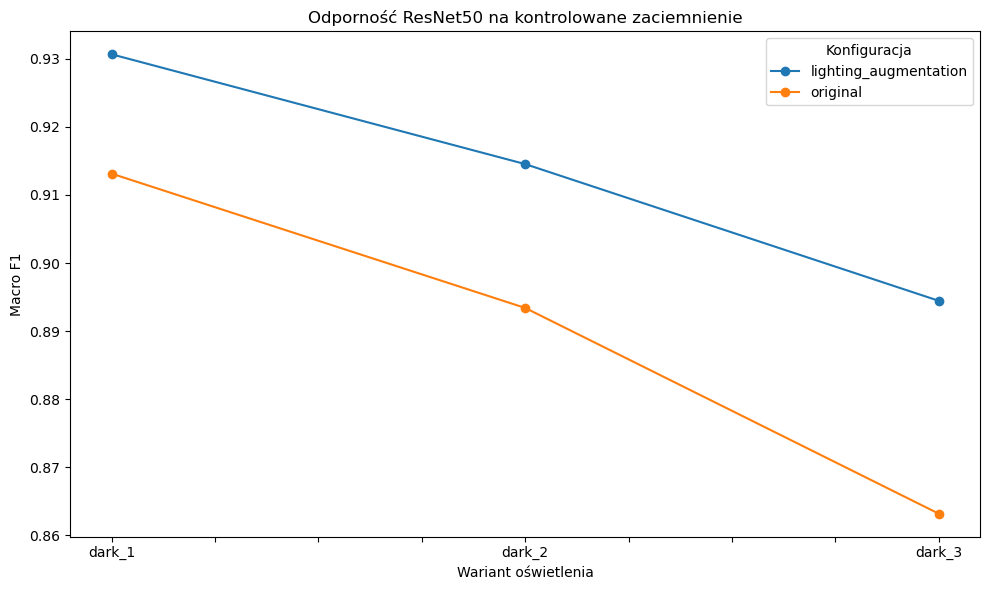

In [16]:
dark_plot = (
    lighting_results_df[
        lighting_results_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        [
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


display(
    dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Odporność ResNet50 na kontrolowane zaciemnienie"
)

ax.set_xlabel(
    "Wariant oświetlenia"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "01_dark_robustness_comparison.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 16. Wybór konfiguracji

Podstawowym kryterium wyboru jest najwyższa średnia wartość `Macro F1` dla `dark_1`, `dark_2` i `dark_3`.

Jako kryteria pomocnicze wykorzystuje się wynik dla `dark_3` oraz spadek `Macro F1` względem obrazu oryginalnego.

In [17]:
best_configuration = (
    robustness_summary.index[0]
)


print(
    "Najlepsza konfiguracja:",
    best_configuration
)


display(
    robustness_summary.loc[
        [best_configuration]
    ]
)

Najlepsza konfiguracja: lighting_augmentation


,mean_dark_macro_f1,dark3_macro_f1,standard_macro_f1,f1_drop_to_dark3
configuration,,,,
lighting_augmentation,0.913216,0.894459,0.930392,0.035933


## 17. Zapis wyników walidacyjnych

In [18]:
standard_validation_df.to_csv(
    METRICS_DIR
    / "lighting_augmentation_standard_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


lighting_results_df.to_csv(
    METRICS_DIR
    / "lighting_augmentation_robustness_validation.csv",
    index=False,
    encoding="utf-8-sig",
)


robustness_summary.to_csv(
    METRICS_DIR
    / "lighting_augmentation_robustness_summary.csv",
    encoding="utf-8-sig",
)


selection = {
    "selected_configuration":
        best_configuration,

    "selection_metric":
        "mean_dark_macro_f1",

    "results":
        robustness_summary.reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "lighting_augmentation_selection.json"
).write_text(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        selection,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "selected_configuration": "lighting_augmentation",
  "selection_metric": "mean_dark_macro_f1",
  "results": [
    {
      "configuration": "lighting_augmentation",
      "mean_dark_macro_f1": 0.9132157423558577,
      "dark3_macro_f1": 0.8944594436284149,
      "standard_macro_f1": 0.9303921972648405,
      "f1_drop_to_dark3": 0.03593275363642556
    },
    {
      "configuration": "original",
      "mean_dark_macro_f1": 0.8899133192414777,
      "dark3_macro_f1": 0.863199546097667,
      "standard_macro_f1": 0.9254608556725615,
      "f1_drop_to_dark3": 0.06226130957489451
    }
  ]
}


## 18. Końcowa ocena na niezależnym zbiorze testowym

Po wyborze konfiguracji na podstawie zbioru walidacyjnego przeprowadzana jest końcowa ocena na `test_final`.

Dla umożliwienia bezpośredniego porównania odporności oceniany jest również bazowy model ResNet50 bez augmentacji oświetleniowej.

Nie są podejmowane dalsze decyzje dotyczące parametrów eksperymentu na podstawie wyników testowych.

In [19]:
selected_config_name = (
    best_configuration
)


selected_model = experiments[
    selected_config_name
][
    "model"
]


baseline_model = experiments[
    "original"
][
    "model"
]


models_for_test = {
    "original":
        baseline_model,

    selected_config_name:
        selected_model,
}


test_results = []


for name, model in (
    models_for_test.items()
):

    configuration = next(
        configuration
        for configuration
        in CONFIGURATIONS
        if configuration[
            "name"
        ] == name
    )


    for variant in LIGHTING_VARIANTS:

        method = "original"


        transform = (
            build_evaluation_transform()
        )


        dataset = (
            ControlledLightingDataset(
                TEST_PATH,
                class_to_idx,
                lighting_variant=variant,
                transform=transform,
            )
        )


        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=False,
        )


        y_true, y_pred, inference_time = (
            predict(
                model,
                loader,
                DEVICE,
            )
        )


        metrics = evaluate_predictions(
            y_true,
            y_pred,
        )


        test_results.append(
            {
                "configuration":
                    name,

                "variant":
                    variant,

                "factor":
                    LIGHTING_FACTORS[
                        variant
                    ],

                "samples":
                    len(dataset),

                "accuracy":
                    metrics[
                        "accuracy"
                    ],

                "macro_precision":
                    metrics[
                        "macro_precision"
                    ],

                "macro_recall":
                    metrics[
                        "macro_recall"
                    ],

                "macro_f1":
                    metrics[
                        "macro_f1"
                    ],

                "inference_time_seconds":
                    inference_time,
            }
        )


final_lighting_df = pd.DataFrame(
    test_results
)


display(
    final_lighting_df
)

,configuration,variant,factor,samples,accuracy,macro_precision,macro_recall,macro_f1,inference_time_seconds
0,original,original,1.0,4298,0.901815,0.889437,0.887256,0.879895,354.796248
1,original,dark_1,0.7,4298,0.887389,0.872089,0.865053,0.859937,343.532653
2,original,dark_2,0.5,4298,0.877385,0.861667,0.855668,0.849428,337.402536
3,original,dark_3,0.3,4298,0.852722,0.837990,0.824800,0.813788,346.167296
4,lighting_augmentation,original,1.0,4298,0.903443,0.889153,0.899150,0.886519,341.463779
5,lighting_augmentation,dark_1,0.7,4298,0.897394,0.879516,0.892460,0.878948,349.385558
6,lighting_augmentation,dark_2,0.5,4298,0.889251,0.870704,0.880568,0.868327,350.868564
7,lighting_augmentation,dark_3,0.3,4298,0.869242,0.853497,0.861312,0.846234,345.002896


## 19. Końcowe porównanie odporności

In [20]:
test_dark = (
    final_lighting_df[
        final_lighting_df[
            "variant"
        ].isin(
            [
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
)


test_dark_summary = (
    test_dark
    .groupby(
        "configuration"
    )
    .agg(
        mean_dark_macro_f1=(
            "macro_f1",
            "mean",
        ),
        mean_dark_accuracy=(
            "accuracy",
            "mean",
        ),
    )
)


test_dark3 = (
    final_lighting_df[
        final_lighting_df[
            "variant"
        ] == "dark_3"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "dark3_macro_f1"
        }
    )
)


test_original = (
    final_lighting_df[
        final_lighting_df[
            "variant"
        ] == "original"
    ]
    [
        [
            "configuration",
            "macro_f1",
        ]
    ]
    .set_index(
        "configuration"
    )
    .rename(
        columns={
            "macro_f1":
                "original_macro_f1"
        }
    )
)


test_summary = (
    test_dark_summary
    .join(
        test_dark3
    )
    .join(
        test_original
    )
)


test_summary[
    "f1_drop_to_dark3"
] = (
    test_summary[
        "original_macro_f1"
    ]
    -
    test_summary[
        "dark3_macro_f1"
    ]
)


display(
    test_summary
)

,mean_dark_macro_f1,mean_dark_accuracy,dark3_macro_f1,original_macro_f1,f1_drop_to_dark3
configuration,,,,,
lighting_augmentation,0.864503,0.885295,0.846234,0.886519,0.040285
original,0.841051,0.872499,0.813788,0.879895,0.066107


## 20. Wizualizacja końcowej odporności

configuration,lighting_augmentation,original
variant,,
original,0.886519,0.879895
dark_1,0.878948,0.859937
dark_2,0.868327,0.849428
dark_3,0.846234,0.813788


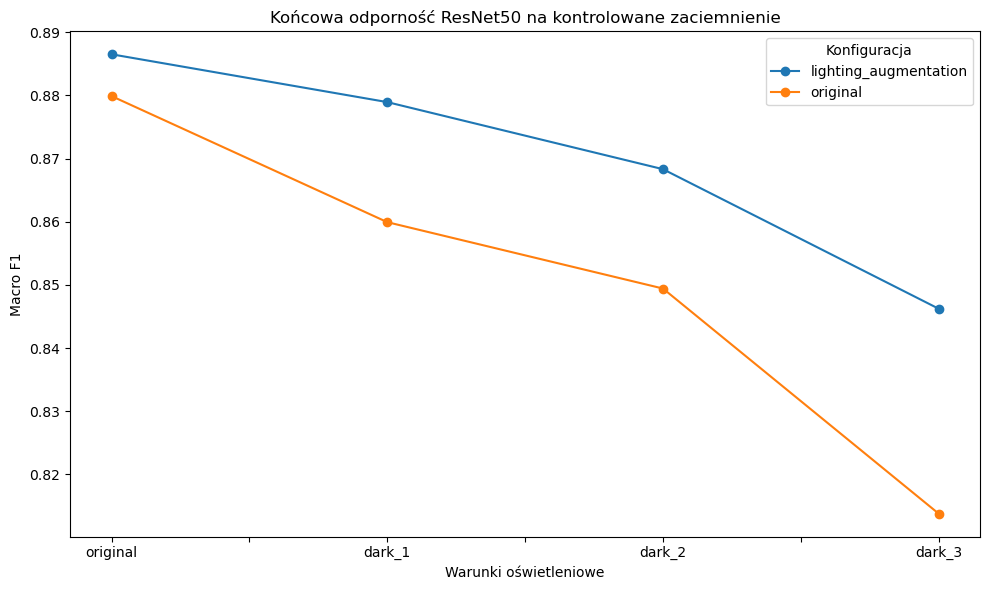

In [21]:
test_dark_plot = (
    final_lighting_df[
        final_lighting_df[
            "variant"
        ].isin(
            [
                "original",
                "dark_1",
                "dark_2",
                "dark_3",
            ]
        )
    ]
    .pivot(
        index="variant",
        columns="configuration",
        values="macro_f1",
    )
    .reindex(
        [
            "original",
            "dark_1",
            "dark_2",
            "dark_3",
        ]
    )
)


display(
    test_dark_plot
)


fig, ax = plt.subplots(
    figsize=(10, 6)
)


test_dark_plot.plot(
    marker="o",
    ax=ax,
)


ax.set_title(
    "Końcowa odporność ResNet50 "
    "na kontrolowane zaciemnienie"
)

ax.set_xlabel(
    "Warunki oświetleniowe"
)

ax.set_ylabel(
    "Macro F1"
)

ax.legend(
    title="Konfiguracja"
)


plt.tight_layout()


fig.savefig(
    FIGURES_DIR
    / "02_final_lighting_augmentation_test.png",
    dpi=250,
    bbox_inches="tight",
)


plt.show()

## 21. Raport klasowy dla końcowego testu

Raport klasowy przygotowano dla obrazu oryginalnego oraz najsilniejszego poziomu zaciemnienia.

In [22]:
per_class_results = []


for name, model in (
    models_for_test.items()
):

    configuration = next(
        configuration
        for configuration
        in CONFIGURATIONS
        if configuration[
            "name"
        ] == name
    )


    for variant in [
        "original",
        "dark_3",
    ]:

        transform = (
            build_evaluation_transform()
        )


        dataset = (
            ControlledLightingDataset(
                TEST_PATH,
                class_to_idx,
                lighting_variant=variant,
                transform=transform,
            )
        )


        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
            pin_memory=False,
        )


        y_true, y_pred, _ = (
            predict(
                model,
                loader,
                DEVICE,
            )
        )


        report = pd.DataFrame(
            classification_report(
                y_true,
                y_pred,
                labels=list(
                    range(
                        len(
                            class_codes
                        )
                    )
                ),
                target_names=[
                    idx_to_class[
                        index
                    ]
                    for index
                    in range(
                        len(
                            class_codes
                        )
                    )
                ],
                output_dict=True,
                zero_division=0,
            )
        ).T


        report = report.iloc[
            :len(class_codes)
        ].copy()


        report[
            "class_code"
        ] = report.index


        report[
            "configuration"
        ] = name


        report[
            "variant"
        ] = variant


        per_class_results.append(
            report
        )


per_class_df = pd.concat(
    per_class_results,
    ignore_index=True,
)


display(
    per_class_df.head()
)

,precision,recall,f1-score,support,class_code,configuration,variant
0,0.650000,0.780000,0.709091,50.0,A-1,original,original
1,1.000000,0.909091,0.952381,11.0,A-11,original,original
2,0.909091,1.000000,0.952381,10.0,A-11a,original,original
3,0.850000,0.809524,0.829268,21.0,A-12a,original,original
4,0.818182,0.818182,0.818182,11.0,A-14,original,original


## 22. Zapis wyników końcowych

In [23]:
final_lighting_df.to_csv(
    METRICS_DIR
    / "final_lighting_augmentation_test.csv",
    index=False,
    encoding="utf-8-sig",
)


test_summary.to_csv(
    METRICS_DIR
    / "final_lighting_augmentation_test_summary.csv",
    encoding="utf-8-sig",
)


per_class_df.to_csv(
    METRICS_DIR
    / "final_lighting_augmentation_test_per_class.csv",
    index=False,
    encoding="utf-8-sig",
)


final_summary = {
    "experiment":
        "lighting_augmentation",

    "model":
        "ResNet50",

    "balancing_strategy":
        "weighted_sampler",

    "selected_configuration":
        selected_config_name,

    "frozen_epochs":
        FROZEN_EPOCHS,

    "fine_tune_epochs":
        FINE_TUNE_EPOCHS,

    "results":
        final_lighting_df.to_dict(
            orient="records"
        ),

    "summary":
        test_summary.reset_index()
        .to_dict(
            orient="records"
        ),
}


(
    METRICS_DIR
    / "final_lighting_augmentation_summary.json"
).write_text(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    ),
    encoding="utf-8",
)


print(
    json.dumps(
        final_summary,
        indent=2,
        ensure_ascii=False,
    )
)

{
  "experiment": "lighting_augmentation",
  "model": "ResNet50",
  "balancing_strategy": "weighted_sampler",
  "selected_configuration": "lighting_augmentation",
  "frozen_epochs": 10,
  "fine_tune_epochs": 5,
  "results": [
    {
      "configuration": "original",
      "variant": "original",
      "factor": 1.0,
      "samples": 4298,
      "accuracy": 0.90181479758027,
      "macro_precision": 0.8894371984416014,
      "macro_recall": 0.887256398764739,
      "macro_f1": 0.8798947136065122,
      "inference_time_seconds": 354.79624769999646
    },
    {
      "configuration": "original",
      "variant": "dark_1",
      "factor": 0.7,
      "samples": 4298,
      "accuracy": 0.8873894834806887,
      "macro_precision": 0.8720887193043608,
      "macro_recall": 0.865052978850555,
      "macro_f1": 0.859937356694822,
      "inference_time_seconds": 343.53265349999856
    },
    {
      "configuration": "original",
      "variant": "dark_2",
      "factor": 0.5,
      "samples": 4298,